In [8]:
from numpy import pi
import pint
from simulation import SimulationConfig, OpticalForceCalculator, DipoleCalculator, SweepRunner
import numpy as np
ureg = pint.UnitRegistry()
import matplotlib.pyplot as plt


In [46]:
lmd = 640 * ureg.nanometer
baseConfig = SimulationConfig(
    wl=lmd,
    R=40 * ureg.nanometer,
    dist=1 * ureg.nanometer,
    angle=np.deg2rad(25),
    psi=pi/2,
    chi=pi/4,
    substrate='Air',
    particle='SiO2',
    amplitude=1,
    show_warnings=False,
    initial_field_type='custom',
    z_beam=10 * ureg.nanometer,
    w0=0.7*lmd
)

# dips = OpticalForceCalculator(baseConfig).compute()

# R_arr = np.linspace(10, 170, 50) * ureg.nanometer
# dist_arr = np.linspace(10, 170, 20) * ureg.nanometer
z_beam_arr = np.linspace(-1200, 1200, 80) * ureg.nanometer
# wl_arr = np.linspace(330, 780, 100) * ureg.nanometer

res, _, _ = SweepRunner(baseConfig, 'z_beam', z_beam_arr, compute_force=True).run()

Custom field parameters set: w0=448.0 nanometer, z_beam=10 nanometer





































































  0%|          | 0/80 [04:52<?, ?it/s]








































































































































































































100%|██████████| 80/80 [00:22<00:00,  3.50it/s]


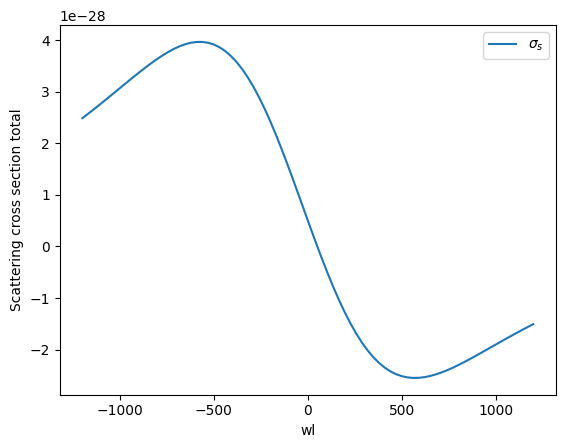

In [47]:
# plt.plot(res.dist, res.Fx, label='Fx')
# plt.plot(res.dist, res.Fy, label='Fy')
plt.plot(res.z_beam[::-1], res.Fz, label='$\\sigma_{s}$')
plt.xlabel('wl')
plt.ylabel('Scattering cross section total')
plt.legend()
plt.show()